# Matching Based on Conversation with Andrew

The goal is to do two sets of Matching.

- **Intent to Treat Matching**: Match those who were admitted to the program (Non-Graduates AND Graduates) and match them against those who did NOT attend the Program (Interviewed and Non-TIP)
- **Treatment Matching**: Match those who graduated from the program against those that did not graduate from the program.

We will Match to determine:
- TIP's affect on Income Earnings
- TIP's affect on Employment
- TIP's affect on Criminal Justice Interactions
- TIP's affect on Recidivism

In [19]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm

In [20]:
all_tip_students = pd.read_csv('TIP_StudentData.csv', parse_dates=['DOB', 'GraduatedDate', 'StartDate', 'EndDate', 'InterviewedDate', 'CreatedDate'])

In [ ]:
# define status
def status(row):
    if not pd.isnull(row['GraduatedDate']):
        return 'Graduated'
    elif (not pd.isnull(row['StartDate'])) & (not pd.isnull(row['EndDate'])) & ((row['EndDate'] - row['StartDate']).days < 120):
        return 'Non Graduated'
    elif (not pd.isnull(row['InterviewedDate'])) & ((pd.isnull(row['EndDate'])) or (row['EndDate'] - row['InterviewedDate']).days < 120):
        return 'Interviewed'
    else:
        return 'None'
    
all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
Graduated        759
Non Graduated    723
Interviewed      550
None             275
Name: count, dtype: int64

In [23]:
tip_sentencing = pd.read_csv('TIP_MergedSentencingData.csv', parse_dates=['DOB', 'DOS', 'StartDate'])
tip_sentencing['age_at_sentencing'] = (tip_sentencing['DOS'] - tip_sentencing['DOB']).dt.days // 365

tip_arrests = pd.read_csv('arrest_data.csv', parse_dates=['ArrestDate', 'StartDate'])
tip_arrests = pd.merge(
    tip_arrests,
    all_tip_students[['tip_id', 'DOB']],
    how='left',
    on='tip_id'
)
tip_arrests['age_at_arrest'] = (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365

tip_wide = tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
tip_wide['value'] = 1
tip_wide = tip_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
tip_wide = tip_wide.reset_index().rename_axis(None, axis=1)

high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in tip_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    tip_wide[new_col] = tip_wide[column]
    drop_cols.append(column)

tip_wide = tip_wide.drop(columns=drop_cols)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)
tip_wide = tip_wide.merge(high_tip_ogs_wide, on='tip_id', how='left').fillna(0)

arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')
tip_earnings['tip_id'] = tip_earnings['tip_id'].astype(int)
tip_earnings['year'] = tip_earnings['quarter'].astype(str).str[:4].astype(int)
tip_earnings['quarter'] = tip_earnings['quarter'].astype(str).str[-1].astype(int)
tip_earnings['quarter'] = tip_earnings['quarter'].replace({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
tip_earnings['year_quarter'] = tip_earnings['year'].astype(str) + '-' + tip_earnings['quarter']
tip_earnings['year_quarter_dt'] = pd.PeriodIndex(tip_earnings['year_quarter'], freq='Q').to_timestamp()
tip_earnings = pd.merge(tip_earnings, tip_sentencing[['tip_id', 'StartDate']], on='tip_id', how='left')
tip_earnings = tip_earnings[tip_earnings['earnings'] != 0]
tip_earnings = tip_earnings.drop(columns=['StartDate'])
tip_earnings = tip_earnings.dropna(subset=['earnings']).reset_index(drop=True)

tip_dob = all_tip_students[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)
tip_earnings['age'] = (tip_earnings['year_quarter_dt'] - tip_earnings['DOB']).dt.days // 365
earnings_wide = tip_earnings[['tip_id', 'age', 'earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['earnings'].sum().reset_index()
earnings_wide = earnings_wide[earnings_wide['age'] > 15]
earnings_wide = earnings_wide[earnings_wide['age'] < 59]

earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)

earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

tip_demo = pd.read_csv('tip_cohort_demographics_rg.csv')[['tip_id', 'gender', 'race', 'census_tract']]
tip_demo['tip_id'] = tip_demo['tip_id'].astype(int)

C:\Users\13429\AppData\Local\Temp\ipykernel_26472\963948376.py:56: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')


In [24]:
tip = pd.merge(
    all_tip_students,
    tip_wide.fillna(0),
    on='tip_id',
    how='left'
)

tip = pd.merge(
    tip,
    arrests_wide.fillna(0),
    on='tip_id',
    how='left'
)

tip = pd.merge(
    tip,
    earnings_wide.fillna(0),
    on='tip_id',
    how='left'
)

tip = pd.merge(
    tip,
    tip_demo.fillna(0),
    on='tip_id',
    how='left'
)

tip[tip_wide.columns] = tip[tip_wide.columns].fillna(0)
tip[arrests_wide.columns] = tip[arrests_wide.columns].fillna(0)
tip[earnings_wide.columns] = tip[earnings_wide.columns].fillna(0)
tip[tip_demo.columns] = tip[tip_demo.columns].fillna(0)

In [25]:
tip.sample(8)

,tip_id,DOB,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,Status,...,52_earnings,53_earnings,54_earnings,55_earnings,56_earnings,57_earnings,58_earnings,gender,race,census_tract
905,906,1994-02-10,2019-06-14,NaT,2019-03-18,2019-06-14,Yes,Introduction to Masonry,2019-03-13,Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,White,4.200348e+10
463,464,1973-07-26,NaT,NaT,NaT,NaT,NaN,Introduction to Masonry,2018-07-12,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Black,4.200305e+10
1211,1212,1980-08-16,NaT,2020-10-08,NaT,NaT,Yes,Introduction to Masonry,2020-10-08,Interviewed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.200310e+10
1303,1304,2000-01-08,2021-11-10,2021-04-27,2021-05-10,2021-11-10,No,Introduction to Masonry,2021-04-27,Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.200348e+10
6,7,1990-01-26,NaT,NaT,2013-08-19,2013-08-27,NaN,Introduction to Masonry,2018-07-12,Non Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.211102e+10
881,882,1994-11-21,2019-05-03,NaT,2019-02-18,2019-05-03,No,Introduction to Masonry,2019-01-28,Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.200313e+10
1112,1113,1990-01-05,2020-03-13,2020-02-11,2020-02-24,2020-03-13,Yes,Introduction to Masonry,2020-02-11,Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.200320e+10
395,396,1973-06-13,NaT,NaT,2016-05-18,2016-05-18,No,Introduction to Masonry,2018-07-12,Non Graduated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Black,4.200352e+10


In [26]:
pcs = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])

pcs['age_at_sentencing'] = ((pcs['DOS'] - pcs['DOB']).dt.days // 365)

pcs = pcs[(pcs['age_at_sentencing'] > 15) & (pcs['age_at_sentencing'] < 59)].reset_index(drop=True)
pcs['age_at_sentencing'] = pcs['age_at_sentencing'].astype(int)

pcs.sample(4)

C:\Users\13429\AppData\Local\Temp\ipykernel_26472\3979129155.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])


,PCS_OFF_ID,DOB,OFF_RACE,OFF_SEX,OGS,DOF,DOS,INCMIN,age_at_sentencing
1091406,1556100.0,1977-10-27,NaN,NaN,1.0,2006-11-15,2007-04-17,6.0,29
408654,1830402.0,1980-05-02,NaN,NaN,5.0,2000-07-14,2001-04-25,2.0,20
1255225,1136960.0,1980-01-17,NaN,NaN,3.0,2007-11-06,2008-05-08,NaN,28
1401408,1247917.0,1989-09-06,NaN,NaN,2.0,2009-07-03,2010-01-29,1.0,20


In [28]:
pcs_wide = pcs[['PCS_OFF_ID', 'age_at_sentencing']].drop_duplicates()
pcs_wide['value'] = 1
pcs_wide = pcs_wide.pivot(index='PCS_OFF_ID', columns='age_at_sentencing', values='value').fillna(0)
pcs_wide = pcs_wide.reset_index().rename_axis(None, axis=1)

high_pcs_ogs = pcs[pcs['OGS'] > 5]
high_pcs_ogs_wide = high_pcs_ogs[['PCS_OFF_ID', 'age_at_sentencing']].drop_duplicates().dropna()
high_pcs_ogs_wide['value'] = 1
high_pcs_ogs_wide = high_pcs_ogs_wide.pivot(index='PCS_OFF_ID', columns='age_at_sentencing', values='value').fillna(0)
high_pcs_ogs_wide = high_pcs_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in pcs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    pcs_wide[new_col] = pcs_wide[column]
    drop_cols.append(column)

pcs_wide = pcs_wide.drop(columns=drop_cols)
drop_cols = []
for column in high_pcs_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_pcs_ogs_wide[new_col] = high_pcs_ogs_wide[column]
    drop_cols.append(column)

high_pcs_ogs_wide = high_pcs_ogs_wide.drop(columns=drop_cols) 
pcs_wide = pcs_wide.merge(high_pcs_ogs_wide, on='PCS_OFF_ID', how='left').fillna(0)

pcs_earnings = pd.read_csv('ui_earnings.txt')
pcs_earnings.dropna(subset=['pcs_off_id'], inplace=True)
pcs_earnings['PCS_OFF_ID'] = pcs_earnings['pcs_off_id'].astype(int)
pcs_earnings['year'] = pcs_earnings['quarter'].astype(str).str[:4].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].astype(str).str[-1].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].replace({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
pcs_earnings['year_quarter'] = pcs_earnings['year'].astype(str) + '-' + pcs_earnings['quarter']
pcs_earnings['year_quarter_dt'] = pd.PeriodIndex(pcs_earnings['year_quarter'], freq='Q').to_timestamp()
pcs_earnings = pcs_earnings[pcs_earnings['earnings'] != 0]
pcs_earnings = pcs_earnings.dropna(subset=['earnings']).reset_index(drop=True)

pcs_dob = pcs[['PCS_OFF_ID', 'DOB']].drop_duplicates()
pcs_earnings = pd.merge(
    pcs_earnings,
    pcs_dob,
    on='PCS_OFF_ID',
    how='left'
)
pcs_earnings['age'] = (pcs_earnings['year_quarter_dt'] - pcs_earnings['DOB']).dt.days // 365
earnings_wide = pcs_earnings[['PCS_OFF_ID', 'age', 'earnings']].copy()
earnings_wide = earnings_wide.groupby(['PCS_OFF_ID', 'age'])['earnings'].sum().reset_index()
earnings_wide = earnings_wide[earnings_wide['age'] > 15]
earnings_wide = earnings_wide[earnings_wide['age'] < 59]
earnings_wide['age'] = earnings_wide['age'].astype(int)

earnings_wide = earnings_wide.pivot(index='PCS_OFF_ID', columns='age', values='earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)

earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

pcs_demo = pd.read_csv('DHS_demographics.csv')[['pcs_off_id', 'gender', 'race', 'census_tract']]
pcs_demo.dropna(subset=['pcs_off_id'], inplace=True)
pcs_demo['PCS_OFF_ID'] = pcs_demo['pcs_off_id'].astype(int)

C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1159411364.py:30: DtypeWarning: Columns (2,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_earnings = pd.read_csv('ui_earnings.txt')


In [29]:
pcs = pd.merge(
    pcs[['PCS_OFF_ID', 'DOB']].drop_duplicates(),
    pcs_wide.drop_duplicates(),
    on='PCS_OFF_ID',
    how='left'
)

pcs = pd.merge(
    pcs,
    earnings_wide.fillna(0),
    on='PCS_OFF_ID',
    how='left'
)

pcs = pd.merge(
    pcs,
    pcs_demo.fillna(0),
    on='PCS_OFF_ID',
    how='left'
)

pcs[pcs_wide.columns] = pcs[pcs_wide.columns].fillna(0)
pcs[earnings_wide.columns] = pcs[earnings_wide.columns].fillna(0)
pcs[pcs_demo.columns] = pcs[pcs_demo.columns].fillna(0)

In [30]:
pcs = pcs.drop_duplicates().reset_index(drop=True)

In [31]:
pcs.sample(8)

,PCS_OFF_ID,DOB,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,...,53_earnings,54_earnings,55_earnings,56_earnings,57_earnings,58_earnings,pcs_off_id,gender,race,census_tract
717586,1423068.0,1979-07-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
701958,1194918.0,1990-07-13,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
745459,1480488.0,1971-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
691000,1766512.0,1984-06-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1766512.0,Male,Black,4.200761e+10
647923,1748431.0,1990-07-05,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
363469,1696038.0,1974-07-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
660044,1350269.0,1963-08-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00
78448,803340.0,1991-11-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.000000e+00


## Treatment Matching

First, we want to identify how Graduates of the program differ from Non-Graduates. 

Let us identify Graduates as Group $i$ and Non-Graduates as Group $j$.
We want to identify the following outcomes:

- $Y_{e}$: Does the person have employment within 1.5 Years of Starting TIP?
- $Y_{o}$: Does the person have an offense within 1.5 Years of Starting TIP?
- $Y_{a}$: Does the person have an arrest within 1.5 Years of Starting TIP?
- $Y_{r}$: Does the person have a recidivism event within 1.5 Years of Starting TIP?

For each participant, we want to consider their employment, income, offenses, and arrests before interacting with TIP, using the variable $X$.

As such, we identify the effect of treatment using the following equation:

$$
logit(p_s) = \beta_{0} + \beta_1(treatment) + \beta_2(X)
$$

Where $p_s$ is the probability of the outcome occuring, $treatment$ is the treatment group, and $X$ is the set of covariates that we are using to match on.

In [41]:
graduate_tip = tip[tip['Status'] == 'Graduated']
graduate_tip = graduate_tip[graduate_tip['StartDate'] < '2023-06-01'].reset_index(drop=True).copy()
# 624 Graduated TIP Students

non_graduate_tip = tip[(tip['Status'] == 'Non Graduated')]
non_graduate_tip = non_graduate_tip[non_graduate_tip['StartDate'] < '2023-06-01'].reset_index(drop=True).copy()
# 514 Non Graduated TIP Students

In [42]:
graduate_tip['age_at_start'] = round((graduate_tip['StartDate'] - graduate_tip['DOB']).dt.days / 365, 3)
non_graduate_tip['age_at_start'] = round((non_graduate_tip['StartDate'] - non_graduate_tip['DOB']).dt.days / 365, 3)
graduate_tip['treatment'] = 1
non_graduate_tip['treatment'] = 0

naive_tip_treatment = pd.concat([
    graduate_tip[['tip_id', 'age_at_start', 'treatment', 'race', 'gender', 'census_tract']],
    non_graduate_tip[['tip_id', 'age_at_start', 'treatment', 'race', 'gender', 'census_tract']],
], axis=0)
naive_tip_treatment = naive_tip_treatment[naive_tip_treatment['age_at_start'] > 15].reset_index(drop=True)

In [43]:
naive_tip_treatment['race'] = naive_tip_treatment['race'].replace(0, 'Unknown')
naive_tip_treatment['gender'] = naive_tip_treatment['gender'].replace(0, 'Unknown')

naive_tip_treatment['census_tract'] = naive_tip_treatment['census_tract'].astype(int).replace(0, 'Unknown')

In [44]:
tip_sentencing_before = tip_sentencing[tip_sentencing['YearsSinceTIP'] < 0]
tip_sentencing_before_ids = tip_sentencing_before['tip_id'].unique()

tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365
tip_arrests_before = tip_arrests[tip_arrests['YearsSinceTIP'] < 0]
tip_arrests_before_ids = tip_arrests_before['tip_id'].unique()

tip_earnings = pd.merge(
    tip_earnings,
    tip[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left'
)
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365
tip_earnings_before = tip_earnings[tip_earnings['YearsSinceTIP'] < 0]
tip_earnings_before = tip_earnings_before[tip_earnings_before['earnings'] != 0]
tip_earnings_before_ids = tip_earnings_before['tip_id'].unique()

In [45]:
naive_tip_treatment['offense_before'] = naive_tip_treatment['tip_id'].isin(tip_sentencing_before_ids).astype(int)
naive_tip_treatment['arrest_before'] = naive_tip_treatment['tip_id'].isin(tip_arrests_before_ids).astype(int)
naive_tip_treatment['earnings_before'] = naive_tip_treatment['tip_id'].isin(tip_earnings_before_ids).astype(int)

In [46]:
def num_offenses_before(row):
    tip_id = row['tip_id']
    if tip_id in tip_sentencing_before_ids:
        return tip_sentencing_before[tip_sentencing_before['tip_id'] == tip_id].shape[0]
    return 0

def num_arrests_before(row):
    tip_id = row['tip_id']
    if tip_id in tip_arrests_before_ids:
        return tip_arrests_before[tip_arrests_before['tip_id'] == tip_id].shape[0]
    return 0

def earnings_year_prior(row):
    tip_id = row['tip_id']
    if tip_id in tip_earnings_before_ids:
        return tip_earnings_before[(tip_earnings_before['tip_id'] == tip_id) & (tip_earnings_before['YearsSinceTIP'] > -1)]['earnings'].sum()
    return 0

def earnings_two_years_prior(row):
    tip_id = row['tip_id']
    if tip_id in tip_earnings_before_ids:
        return tip_earnings_before[(tip_earnings_before['tip_id'] == tip_id) & (tip_earnings_before['YearsSinceTIP'] > -2)]['earnings'].sum()
    return 0

def job_right_before_tip(row):
    tip_id = row['tip_id']
    if tip_id in tip_earnings_before_ids:
        return (tip_earnings_before[(tip_earnings_before['tip_id'] == tip_id) & (tip_earnings_before['YearsSinceTIP'] > -0.5)]['earnings'].sum() > 0).astype(int)
    return 0

In [47]:
naive_tip_treatment['num_offenses_before'] = naive_tip_treatment.apply(num_offenses_before, axis=1)
naive_tip_treatment['num_arrests_before'] = naive_tip_treatment.apply(num_arrests_before, axis=1)
naive_tip_treatment['earnings_year_prior'] = naive_tip_treatment.apply(earnings_year_prior, axis=1)
naive_tip_treatment['earnings_two_years_prior'] = naive_tip_treatment.apply(earnings_two_years_prior, axis=1)
naive_tip_treatment['job_right_before_tip'] = naive_tip_treatment.apply(job_right_before_tip, axis=1)

In [48]:
def employment_outcome(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def employment_outcome_earnings(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ]['earnings'].sum()

def offense_outcome(row):
    tip_id = row['tip_id']
    return tip_sentencing[
        (tip_sentencing['tip_id'] == tip_id) &
        (tip_sentencing['YearsSinceTIP'] > 0) &
        (tip_sentencing['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def arrest_outcome(row):
    tip_id = row['tip_id']
    return tip_arrests[
        (tip_arrests['tip_id'] == tip_id) &
        (tip_arrests['YearsSinceTIP'] > 0) &
        (tip_arrests['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def year_start(row):
    tip_id = row['tip_id']
    return tip[tip['tip_id'] == tip_id]['StartDate'].dt.year.values[0]

In [49]:
naive_tip_treatment['employment_outcome'] = naive_tip_treatment.apply(employment_outcome, axis=1).astype(int)
naive_tip_treatment['employment_outcome_earnings'] = naive_tip_treatment.apply(employment_outcome_earnings, axis=1)
naive_tip_treatment['offense_outcome'] = naive_tip_treatment.apply(offense_outcome, axis=1).astype(int)
naive_tip_treatment['arrest_outcome'] = naive_tip_treatment.apply(arrest_outcome, axis=1).astype(int)

naive_tip_treatment['year_TIP'] = naive_tip_treatment.apply(year_start, axis=1)

In [50]:
Y_has_employment = naive_tip_treatment[['employment_outcome']]
X_values = naive_tip_treatment[['treatment']].copy()
X_values[['year_TIP']] = StandardScaler().fit_transform(naive_tip_treatment[['year_TIP']])
X_values[['offense_before', 'arrest_before', 'job_right_before_tip']] = naive_tip_treatment[['offense_before', 'arrest_before', 'job_right_before_tip']]

X_values[['num_offenses_before', 'num_arrests_before']] = StandardScaler().fit_transform(
    naive_tip_treatment[['num_offenses_before', 'num_arrests_before']]
)

X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(
    naive_tip_treatment[['earnings_two_years_prior']]
)

# Interaction Terms for Treatment
# X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
# X_values['treatment:offense_before'] = X_values['treatment'] * X_values['offense_before']
# X_values['treatment:arrest_before'] = X_values['treatment'] * X_values['arrest_before']

In [51]:
X_values.columns

Index(['treatment', 'year_TIP', 'offense_before', 'arrest_before',
       'job_right_before_tip', 'num_offenses_before', 'num_arrests_before',
       'earnings_two_years_prior'],
      dtype='object')

In [52]:
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.598831
year_TIP,1.379244
offense_before,3.062673
arrest_before,2.697881
job_right_before_tip,1.912449
num_offenses_before,1.954960
num_arrests_before,1.901427
earnings_two_years_prior,1.163383


<Axes: xlabel='pscore', ylabel='Density'>

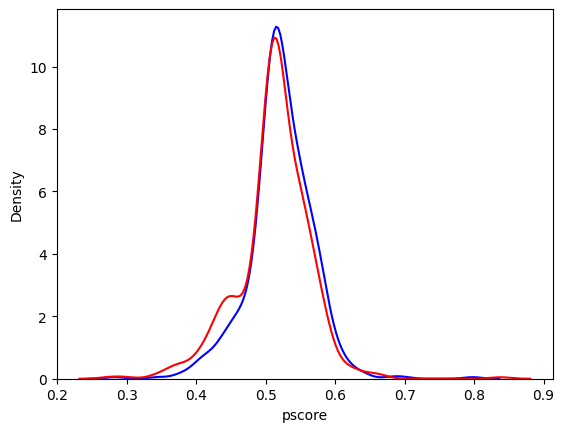

In [53]:
vars_to_check = [
    'year_TIP',
    'offense_before',
    'arrest_before',
    'job_right_before_tip',
    'num_offenses_before',
    'num_arrests_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()

psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])

X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Graduates', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non Graduates', color='red')

In [54]:
X_values = sm.add_constant(X_values)
logit_has_employment = sm.Logit(Y_has_employment, X_values).fit()

logit_has_employment.summary()

Optimization terminated successfully.
         Current function value: 0.413772
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1199
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.3686
Time:                        14:38:06   Log-Likelihood:                -499.84
converged:                       True   LL-Null:                       -791.67
Covariance Type:            nonrobust   LLR p-value:                7.593e-121
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.5611      0.171     -3.285      0.001      -0.896      -0.226
treatment                    0.6240      0.162      3.857      0.000       0.307       0.941
year_TIP                     1.0714      0.101     10.572      0.000       0.873       1.270
offense_before               0.2753      0.239      1.149      0.250      -0.194       0.745
arrest_before                1.0265      0.275      3.733      0.000       0.488       1.566
job_right_before_tip         2.0446      0.222      9.212      0.000       1.610       2.480
num_offenses_before         -0.2062      0.122     -1.687      0.092      -0.446       0.033
num_arrests_before           0.0250      0.116      0.215      0.829      -0.202       0.252
earnings_two_years_prior    -0.0577      0.099     -0.583      0.560      -0.252       0.136
============================================================================================
"""

In [55]:
logit_has_employment_summary = logit_has_employment.summary2().tables[1].reset_index()

In [56]:
print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

                      index     Coef.         P>|z|
0                     const -0.561124  1.020289e-03
1                 treatment  0.624040  1.146477e-04
2                  year_TIP  1.071365  4.001966e-26
3            offense_before  0.275257  2.504246e-01
4             arrest_before  1.026540  1.895531e-04
5      job_right_before_tip  2.044579  3.196834e-20
6       num_offenses_before -0.206203  9.168921e-02
7        num_arrests_before  0.024976  8.294649e-01
8  earnings_two_years_prior -0.057738  5.597462e-01


In [58]:
X_values.treatment.value_counts()

treatment
1    624
0    584
Name: count, dtype: int64

Our model is as follows:

$$
logit(p_e) = \beta_{0} + \beta_1(treatment) + \beta_2(year\_tip) + \beta_3(race = Black) \\ + \beta_4(gender = Male) + \beta_5(has\_offense\_prior) + \beta_6(has\_arrest\_prior) + \\ \beta_7(has\_job\_right\_before) + \beta_8(num\_offenses\_prior) + \beta_9(num\_arrests\_prior) + \\ \beta_{10}(earnings\_two_\_years\_prior) + \beta_{11}(treatment \times year\_tip) + \\ \beta_{12}(treatment \times has\_offense\_prior) + \beta_{13}(treatment \times has\_arrest\_prior)
$$

The naive model shows the following for how the probability of employment 1.5 years after starting TIP is affected by graduating from TIP and other covariates:
- Having a job right before TIP is the strongest predictor of employment - the odds of employment increases by 8x for those who have a job right before TIP.
- TIP's effectiveness in job outcomes has increased throughout the years. We are seeing an increase in employment outcomes for TIP cohorts throughout the years. (2.7x increase in employment outcomes for every 3.3 change in years)
- Graduating in of itself is not a strong predictor of employment outcomes.
- Students who had an arrest before had a stronger benefit from Graduating from TIP - graduating increased their odds 4x more than we'd otherwise expect.
- Students who had an offense before had a strong benefit from Graduating from TIP - graduating increased their odds 2x more than we'd otherwise expect.

Currently, this model uses 624 Graduates and 572 Non-Graduates. Using Propensity Score Matching, we see that the Propensity Scores have very strong overlap. As such, there is no need to trim the data by Propensity Score.

In [59]:
Y_offense = naive_tip_treatment[['offense_outcome']]
logit_has_offense = sm.Logit(Y_offense, X_values).fit()
logit_has_offense.summary()

Optimization terminated successfully.
         Current function value: 0.305372
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        offense_outcome   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1199
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1236
Time:                        15:03:54   Log-Likelihood:                -368.89
converged:                       True   LL-Null:                       -420.93
Covariance Type:            nonrobust   LLR p-value:                 6.261e-19
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -3.3235      0.255    -13.022      0.000      -3.824      -2.823
treatment                   -0.2345      0.193     -1.213      0.225      -0.613       0.144
year_TIP                    -0.6824      0.131     -5.220      0.000      -0.939      -0.426
offense_before               1.3680      0.272      5.021      0.000       0.834       1.902
arrest_before                0.8700      0.290      2.998      0.003       0.301       1.439
job_right_before_tip         0.3704      0.248      1.495      0.135      -0.115       0.856
num_offenses_before         -0.0021      0.111     -0.019      0.985      -0.219       0.215
num_arrests_before          -0.1476      0.130     -1.135      0.256      -0.402       0.107
earnings_two_years_prior     0.1453      0.081      1.802      0.072      -0.013       0.303
============================================================================================
"""

Our model is still of the same format:

$$
logit(p_o) = \beta_{0} + \beta_1(treatment) + \beta_2(year\_tip) + \dots
$$

And shows the following:
- In general, the model is not a strong predictor of whether or not someone will have an offense within 1.5 years of starting TIP.
- Having an offense or arrest before TIP is a stronger predictor of whether or not someone will have an offense after TIP, compared to their graduation status.
- The data does show that TIP participants have a lower rate of offenses throughout the years. (2x decrease in offenses for every 3.3 change in years)


In [60]:
Y_arrest = naive_tip_treatment[['arrest_outcome']]
logit_has_arrest = sm.Logit(Y_arrest, X_values).fit()
logit_has_arrest.summary()

Optimization terminated successfully.
         Current function value: 0.343753
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         arrest_outcome   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1199
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.07571
Time:                        15:04:05   Log-Likelihood:                -415.25
converged:                       True   LL-Null:                       -449.27
Covariance Type:            nonrobust   LLR p-value:                 1.213e-11
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.8175      0.214    -13.164      0.000      -3.237      -2.398
treatment                   -0.1722      0.182     -0.944      0.345      -0.530       0.185
year_TIP                     0.0260      0.118      0.220      0.826      -0.206       0.258
offense_before               0.9329      0.256      3.639      0.000       0.431       1.435
arrest_before                0.9409      0.257      3.666      0.000       0.438       1.444
job_right_before_tip         0.2592      0.212      1.221      0.222      -0.157       0.675
num_offenses_before         -0.0594      0.115     -0.519      0.604      -0.284       0.165
num_arrests_before          -0.1541      0.113     -1.368      0.171      -0.375       0.067
earnings_two_years_prior     0.1139      0.075      1.524      0.127      -0.033       0.260
============================================================================================
"""

Our model is not conclusive - the covariates are not strong predictors of whether or not someone will be arrested within 1.5 years of starting TIP. This makes sense, as our arrest data is not robust, especially for later cohorts.

In [61]:
recid = naive_tip_treatment[naive_tip_treatment['offense_before'] == 1].copy()

Y_recid = recid[['offense_outcome']]
X_values = recid[['treatment']].copy()
X_values[['year_TIP']] = StandardScaler().fit_transform(recid[['year_TIP']])
X_values[['arrest_before', 'job_right_before_tip']] = recid[['arrest_before', 'job_right_before_tip']]

X_values[['num_offenses_before', 'num_arrests_before']] = StandardScaler().fit_transform(
    recid[['num_offenses_before', 'num_arrests_before']]
)

X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(
    recid[['earnings_two_years_prior']]
)

# Interaction Terms for Treatment
X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
X_values['treatment:arrest_before'] = X_values['treatment'] * X_values['arrest_before']

In [62]:
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,2.526301
year_TIP,2.776884
arrest_before,3.270761
job_right_before_tip,1.862424
num_offenses_before,1.128335
num_arrests_before,1.651158
earnings_two_years_prior,1.177629
treatment:year_TIP,2.664734
treatment:arrest_before,3.725151


<Axes: xlabel='pscore', ylabel='Density'>

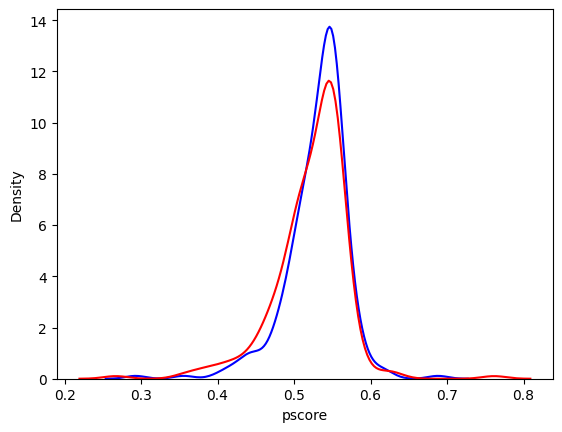

In [63]:
vars_to_check = [
    'year_TIP',
    'arrest_before',
    'job_right_before_tip',
    'num_offenses_before',
    'num_arrests_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()

psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])

X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Graduates', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non Graduates', color='red')

In [64]:
X_values = sm.add_constant(X_values)
logit_recid = sm.Logit(Y_recid, X_values).fit()
logit_recid.summary()

Optimization terminated successfully.
         Current function value: 0.463087
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        offense_outcome   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06050
Time:                        15:04:25   Log-Likelihood:                -242.66
converged:                       True   LL-Null:                       -258.28
Covariance Type:            nonrobust   LLR p-value:                 0.0002682
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.0109      0.326     -6.176      0.000      -2.649      -1.373
treatment                    0.0958      0.384      0.249      0.803      -0.658       0.849
year_TIP                    -0.7783      0.218     -3.565      0.000      -1.206      -0.350
arrest_before                1.0521      0.455      2.314      0.021       0.161       1.943
job_right_before_tip         0.1855      0.292      0.635      0.526      -0.387       0.758
num_offenses_before          0.0095      0.119      0.080      0.936      -0.223       0.242
num_arrests_before          -0.2207      0.192     -1.150      0.250      -0.597       0.155
earnings_two_years_prior     0.1906      0.119      1.599      0.110      -0.043       0.424
treatment:year_TIP           0.0878      0.284      0.310      0.757      -0.468       0.644
treatment:arrest_before     -0.6172      0.560     -1.102      0.270      -1.715       0.480
============================================================================================
"""

Our model is as follows:

$$
logit(p_e) = \beta_{0} + \beta_1(treatment) + \beta_2(year\_tip) + \beta_3(has\_arrest\_prior) + \\ \beta_4(has\_job\_right\_before) + \beta_5(num\_offenses\_prior) + \beta_6(num\_arrests\_prior) + \\ \beta_{7}(earnings\_two_\_years\_prior) + \beta_{8}(treatment \times year\_tip) + \\ \beta_{9}(treatment \times has\_arrest\_prior)
$$

In general, the model is not a strong predictor of whether or not someone will re-offend within 1.5 years of starting TIP. 

## Intent to Treat Matching

Now, we want to identify how Participants of the program differ from Non-Participants.

Let us identify Graduates and Non-Graduates as Group $i$, and Interviewed and Non-TIP as Group $j$.
We want to identify the following outcomes:

- $Y_{e}$: Does the person have employment within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{o}$: Does the person have an offense within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{a}$: Does the person have an arrest within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{r}$: Does the person have a recidivism event within 1.5 Years of Starting TIP (based on Matching)?

For each participant, we want to consider their employment, income, offenses, and arrests before interacting with TIP, using the variable $X$. For the non-participants, we need to do matching to give us a baseline TIP start.

In [65]:
tip_pcs = tip_sentencing.PCS_OFF_ID.unique()

In [66]:
participated = tip[(tip['Status'] == 'Graduated') | (tip['Status'] == 'Non Graduated')].copy()
participated = participated[participated['StartDate'] < '2023-06-01']
participated['days_TIP'] = (participated.EndDate - participated.StartDate).dt.days
participated = participated[participated['days_TIP'] > 0].reset_index(drop=True).copy()
participated['days_TIP'] = participated.apply(lambda x: 77 if x['Status'] == 'Graduated' else x['days_TIP'], axis=1)

non_participated = pd.concat([
    tip[tip['Status'] == 'Interviewed'],
    pcs[~pcs['PCS_OFF_ID'].isin(tip_pcs)],
], axis=0).copy()

In [67]:
reordered_cols = [
    'tip_id',
    'PCS_OFF_ID',
    'DOB',
    'gender',
    'race',
    'census_tract',
    'GraduatedDate',
    'InterviewedDate',
    'StartDate',
    'EndDate',
    'DriversLicense',
    'Course',
    'CreatedDate',
    'Status',
    '16_sentencing_age',
    '17_sentencing_age',
    '18_sentencing_age',
    '19_sentencing_age',
    '20_sentencing_age',
    '21_sentencing_age',
    '22_sentencing_age',
    '23_sentencing_age',
    '24_sentencing_age',
    '25_sentencing_age',
    '26_sentencing_age',
    '27_sentencing_age',
    '28_sentencing_age',
    '29_sentencing_age',
    '30_sentencing_age',
    '31_sentencing_age',
    '32_sentencing_age',
    '33_sentencing_age',
    '34_sentencing_age',
    '35_sentencing_age',
    '36_sentencing_age',
    '37_sentencing_age',
    '38_sentencing_age',
    '39_sentencing_age',
    '40_sentencing_age',
    '41_sentencing_age',
    '42_sentencing_age',
    '43_sentencing_age',
    '44_sentencing_age',
    '45_sentencing_age',
    '46_sentencing_age',
    '47_sentencing_age',
    '48_sentencing_age',
    '49_sentencing_age',
    '50_sentencing_age',
    '51_sentencing_age',
    '52_sentencing_age',
    '53_sentencing_age',
    '54_sentencing_age',
    '55_sentencing_age',
    '56_sentencing_age',
    '57_sentencing_age',
    '58_sentencing_age',
    '16_sentencing_age_high_ogs',
    '17_sentencing_age_high_ogs',
    '18_sentencing_age_high_ogs',
    '19_sentencing_age_high_ogs',
    '20_sentencing_age_high_ogs',
    '21_sentencing_age_high_ogs',
    '22_sentencing_age_high_ogs',
    '23_sentencing_age_high_ogs',
    '24_sentencing_age_high_ogs',
    '25_sentencing_age_high_ogs',
    '26_sentencing_age_high_ogs',
    '27_sentencing_age_high_ogs',
    '28_sentencing_age_high_ogs',
    '29_sentencing_age_high_ogs',
    '30_sentencing_age_high_ogs',
    '31_sentencing_age_high_ogs',
    '32_sentencing_age_high_ogs',
    '33_sentencing_age_high_ogs',
    '34_sentencing_age_high_ogs',
    '35_sentencing_age_high_ogs',
    '36_sentencing_age_high_ogs',
    '37_sentencing_age_high_ogs',
    '38_sentencing_age_high_ogs',
    '39_sentencing_age_high_ogs',
    '40_sentencing_age_high_ogs',
    '41_sentencing_age_high_ogs',
    '42_sentencing_age_high_ogs',
    '43_sentencing_age_high_ogs',
    '44_sentencing_age_high_ogs',
    '45_sentencing_age_high_ogs',
    '46_sentencing_age_high_ogs',
    '47_sentencing_age_high_ogs',
    '48_sentencing_age_high_ogs',
    '49_sentencing_age_high_ogs',
    '50_sentencing_age_high_ogs',
    '51_sentencing_age_high_ogs',
    '52_sentencing_age_high_ogs',
    '53_sentencing_age_high_ogs',
    '54_sentencing_age_high_ogs',
    '55_sentencing_age_high_ogs',
    '56_sentencing_age_high_ogs',
    '57_sentencing_age_high_ogs',
    '58_sentencing_age_high_ogs',
    '15_arrest_age',
    '16_arrest_age',
    '17_arrest_age',
    '18_arrest_age',
    '19_arrest_age',
    '20_arrest_age',
    '21_arrest_age',
    '22_arrest_age',
    '23_arrest_age',
    '24_arrest_age',
    '25_arrest_age',
    '26_arrest_age',
    '27_arrest_age',
    '28_arrest_age',
    '29_arrest_age',
    '30_arrest_age',
    '31_arrest_age',
    '32_arrest_age',
    '33_arrest_age',
    '34_arrest_age',
    '35_arrest_age',
    '36_arrest_age',
    '37_arrest_age',
    '38_arrest_age',
    '39_arrest_age',
    '40_arrest_age',
    '41_arrest_age',
    '42_arrest_age',
    '43_arrest_age',
    '44_arrest_age',
    '45_arrest_age',
    '46_arrest_age',
    '47_arrest_age',
    '48_arrest_age',
    '49_arrest_age',
    '50_arrest_age',
    '51_arrest_age',
    '52_arrest_age',
    '53_arrest_age',
    '16_earnings',
    '17_earnings',
    '18_earnings',
    '19_earnings',
    '20_earnings',
    '21_earnings',
    '22_earnings',
    '23_earnings',
    '24_earnings',
    '25_earnings',
    '26_earnings',
    '27_earnings',
    '28_earnings',
    '29_earnings',
    '30_earnings',
    '31_earnings',
    '32_earnings',
    '33_earnings',
    '34_earnings',
    '35_earnings',
    '36_earnings',
    '37_earnings',
    '38_earnings',
    '39_earnings',
    '40_earnings',
    '41_earnings',
    '42_earnings',
    '43_earnings',
    '44_earnings',
    '45_earnings',
    '46_earnings',
    '47_earnings',
    '48_earnings',
    '49_earnings',
    '50_earnings',
    '51_earnings',
    '52_earnings',
    '53_earnings',
    '54_earnings',
    '55_earnings',
    '56_earnings',
    '57_earnings',
    '58_earnings'
]

In [68]:
non_participated = non_participated[reordered_cols].copy()

In [69]:
reordered_cols = [
    'tip_id',
    'days_TIP',
    'DOB',
    'gender',
    'race',
    'census_tract',
    'GraduatedDate',
    'InterviewedDate',
    'StartDate',
    'EndDate',
    'DriversLicense',
    'Course',
    'CreatedDate',
    'Status',
    '16_sentencing_age',
    '17_sentencing_age',
    '18_sentencing_age',
    '19_sentencing_age',
    '20_sentencing_age',
    '21_sentencing_age',
    '22_sentencing_age',
    '23_sentencing_age',
    '24_sentencing_age',
    '25_sentencing_age',
    '26_sentencing_age',
    '27_sentencing_age',
    '28_sentencing_age',
    '29_sentencing_age',
    '30_sentencing_age',
    '31_sentencing_age',
    '32_sentencing_age',
    '33_sentencing_age',
    '34_sentencing_age',
    '35_sentencing_age',
    '36_sentencing_age',
    '37_sentencing_age',
    '38_sentencing_age',
    '39_sentencing_age',
    '40_sentencing_age',
    '41_sentencing_age',
    '42_sentencing_age',
    '43_sentencing_age',
    '44_sentencing_age',
    '45_sentencing_age',
    '46_sentencing_age',
    '47_sentencing_age',
    '48_sentencing_age',
    '49_sentencing_age',
    '50_sentencing_age',
    '51_sentencing_age',
    '52_sentencing_age',
    '53_sentencing_age',
    '54_sentencing_age',
    '58_sentencing_age',
    '16_sentencing_age_high_ogs',
    '17_sentencing_age_high_ogs',
    '18_sentencing_age_high_ogs',
    '19_sentencing_age_high_ogs',
    '20_sentencing_age_high_ogs',
    '21_sentencing_age_high_ogs',
    '22_sentencing_age_high_ogs',
    '23_sentencing_age_high_ogs',
    '24_sentencing_age_high_ogs',
    '25_sentencing_age_high_ogs',
    '26_sentencing_age_high_ogs',
    '27_sentencing_age_high_ogs',
    '28_sentencing_age_high_ogs',
    '29_sentencing_age_high_ogs',
    '30_sentencing_age_high_ogs',
    '31_sentencing_age_high_ogs',
    '32_sentencing_age_high_ogs',
    '33_sentencing_age_high_ogs',
    '34_sentencing_age_high_ogs',
    '35_sentencing_age_high_ogs',
    '36_sentencing_age_high_ogs',
    '37_sentencing_age_high_ogs',
    '38_sentencing_age_high_ogs',
    '39_sentencing_age_high_ogs',
    '40_sentencing_age_high_ogs',
    '41_sentencing_age_high_ogs',
    '42_sentencing_age_high_ogs',
    '43_sentencing_age_high_ogs',
    '44_sentencing_age_high_ogs',
    '45_sentencing_age_high_ogs',
    '46_sentencing_age_high_ogs',
    '47_sentencing_age_high_ogs',
    '48_sentencing_age_high_ogs',
    '51_sentencing_age_high_ogs',
    '52_sentencing_age_high_ogs',
    '58_sentencing_age_high_ogs',
    '15_arrest_age',
    '16_arrest_age',
    '17_arrest_age',
    '18_arrest_age',
    '19_arrest_age',
    '20_arrest_age',
    '21_arrest_age',
    '22_arrest_age',
    '23_arrest_age',
    '24_arrest_age',
    '25_arrest_age',
    '26_arrest_age',
    '27_arrest_age',
    '28_arrest_age',
    '29_arrest_age',
    '30_arrest_age',
    '31_arrest_age',
    '32_arrest_age',
    '33_arrest_age',
    '34_arrest_age',
    '35_arrest_age',
    '36_arrest_age',
    '37_arrest_age',
    '38_arrest_age',
    '39_arrest_age',
    '40_arrest_age',
    '41_arrest_age',
    '42_arrest_age',
    '43_arrest_age',
    '44_arrest_age',
    '45_arrest_age',
    '46_arrest_age',
    '47_arrest_age',
    '48_arrest_age',
    '49_arrest_age',
    '50_arrest_age',
    '51_arrest_age',
    '52_arrest_age',
    '53_arrest_age',
    '16_earnings',
    '17_earnings',
    '18_earnings',
    '19_earnings',
    '20_earnings',
    '21_earnings',
    '22_earnings',
    '23_earnings',
    '24_earnings',
    '25_earnings',
    '26_earnings',
    '27_earnings',
    '28_earnings',
    '29_earnings',
    '30_earnings',
    '31_earnings',
    '32_earnings',
    '33_earnings',
    '34_earnings',
    '35_earnings',
    '36_earnings',
    '37_earnings',
    '38_earnings',
    '39_earnings',
    '40_earnings',
    '41_earnings',
    '42_earnings',
    '43_earnings',
    '44_earnings',
    '45_earnings',
    '46_earnings',
    '47_earnings',
    '48_earnings',
    '49_earnings',
    '50_earnings',
    '51_earnings',
    '52_earnings',
    '53_earnings',
    '54_earnings',
    '55_earnings',
    '56_earnings',
    '57_earnings',
    '58_earnings'
]

In [70]:
participated = participated[reordered_cols].copy()

In [71]:
participated['yob'] = participated['DOB'].dt.year
non_participated['yob'] = non_participated['DOB'].dt.year

participated['census_strict_prefix'] = participated['census_tract'].astype(str).str[:7]
non_participated['census_strict_prefix'] = non_participated['census_tract'].astype(str).str[:7]

participated['census_prefix'] = participated['census_tract'].astype(str).str[:5]
non_participated['census_prefix'] = non_participated['census_tract'].astype(str).str[:5]

ogs_cols = participated.columns
ogs_cols = [col for col in ogs_cols if 'ogs' in col]

participated['has_ogs'] = participated[ogs_cols].sum(axis=1) > 0
non_participated['has_ogs'] = non_participated[ogs_cols].sum(axis=1) > 0


In [72]:
sentencing_cols = [col for col in participated.columns if (('_sentencing_age' in col) and ('ogs' not in col))]

participated['min_sentencing_age'] = participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
participated['num_sentences_before_25'] = participated[sentencing_cols].iloc[:, :8].sum(axis=1)

non_participated['min_sentencing_age'] = non_participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
non_participated['num_sentences_before_25'] = non_participated[sentencing_cols].iloc[:, :8].sum(axis=1)

participated['min_ogs_age'] = participated[ogs_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
participated['num_ogs_before_25'] = participated[ogs_cols].iloc[:, :8].sum(axis=1)

non_participated['min_ogs_age'] = non_participated[ogs_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
non_participated['num_ogs_before_25'] = non_participated[ogs_cols].iloc[:, :8].sum(axis=1)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:3: SyntaxWarning: invalid escape sequence '\d'
  participated['min_sentencing_age'] = participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:6: SyntaxWarning: invalid escape sequence '\d'
  non_participated['min_sentencing_age'] = non_participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:9: SyntaxWarning: invalid escape sequence '\d'
  participa

# Matching

We will use Exact Matching followed by Fuzzy Matching to identify the best matches for each participant.

In [43]:
# all_saved_matches = []
# seen_pcs = set()
# unmatched = []

# for _, tip_participant in tqdm.tqdm(participated.iterrows(), unit="TIP ID", total=len(participated), desc=f"Current Unmatched: {len(unmatched)}"):
#     earnings_cols = {}
#     sentencing_cols = []
#     sentencing_uncols = []
#     attr_cols = {}
#     sentencing_ages = (tip_participant.filter(like='sentencing_age', axis=0))
#     sentencing_ages = sentencing_ages[sentencing_ages == 1]
#     sentencing_ages = [col for col in sentencing_ages.index if 'ogs' not in col]
#     if len(sentencing_ages) > 0:
#         sentencing_cols = sentencing_ages
#         min_age = int(sentencing_ages[0].split('_')[0])
#         max_age = int(sentencing_ages[-1].split('_')[0])
#         if min_age != max_age:
#             for i in range(min_age, max_age + 1):
#                 if str(i) + '_sentencing_age' not in sentencing_cols:
#                     sentencing_uncols.append(str(i) + '_sentencing_age')
#         if min_age != 17:
#             for i in range(17, min_age):
#                 sentencing_uncols.append(str(i) + '_sentencing_age')
#     if not pd.isna(tip_participant['race']):
#         attr_cols['race'] = tip_participant['race']
#     if not pd.isna(tip_participant['gender']):
#         attr_cols['gender'] = tip_participant['gender']
#     if not pd.isna(tip_participant['yob']):
#         attr_cols['yob'] = tip_participant['yob']
#     if not pd.isna(tip_participant['census_tract']):
#         attr_cols['census_strict_prefix'] = tip_participant['census_strict_prefix']
#     if not pd.isna(tip_participant['has_ogs']):
#         attr_cols['has_ogs'] = tip_participant['has_ogs']

#     matches = non_participated[non_participated['PCS_OFF_ID'].isin(seen_pcs) == False]
#     matches = matches[matches[sentencing_cols].eq(1).all(axis=1) & matches[sentencing_uncols].eq(0).all(axis=1)]

#     if len(matches) == 0:
#         matches = non_participated[non_participated['PCS_OFF_ID'].isin(seen_pcs) == False]
#         new_matches = matches[matches['num_sentences_before_25'] == tip_participant['num_sentences_before_25']]
#         if len(new_matches) == 0:
#             new_matches = matches[matches['num_sentences_before_25'].between(
#                 tip_participant['num_sentences_before_25'] - 1,
#                 tip_participant['num_sentences_before_25'] + 1
#             )]
#         matches = new_matches.copy()

#     if attr_cols.get('race'):
#         matches = matches[matches['race'] == attr_cols['race']]
#     if attr_cols.get('gender'):
#         matches = matches[matches['gender'] == attr_cols['gender']]
#     if attr_cols.get('yob'):
#         matches = matches[(matches['yob'] >= attr_cols['yob'] - 1) & (matches['yob'] <= attr_cols['yob'] + 1)]
#     if attr_cols.get('census_strict_prefix'):
#         new_matches = matches[matches['census_strict_prefix'] == attr_cols['census_strict_prefix']]
#         if len(matches) == 0:
#             new_matches = matches[matches['census_prefix'] == tip_participant['census_prefix']]
#         matches = new_matches.copy()
#     if attr_cols.get('has_ogs'):
#         matches = matches[matches['has_ogs'] == attr_cols['has_ogs']]

#     if len(matches) > 5:
#         new_matches = matches[matches['num_ogs_before_25'] == tip_participant['num_ogs_before_25']]
#         if len(new_matches) == 0:
#             new_matches = matches
#         if len(new_matches) > 5:
#             new_matches = matches[matches['num_sentences_before_25'] == tip_participant['num_sentences_before_25']]
#             if len(new_matches) == 0:
#                 new_matches = matches
#     matches = new_matches.copy()
    
#     saved_matches = matches[['PCS_OFF_ID', 'tip_id']].copy()
#     saved_matches['matched_tip_id'] = tip_participant['tip_id']

#     cutoff = min(4, len(matches))
#     saved_matches = saved_matches.sample(cutoff, random_state=1).copy()

#     all_saved_matches.append(saved_matches)
#     seen_pcs.update(saved_matches['PCS_OFF_ID'].values)

#     if len(matches) == 0:
#         unmatched.append(tip_participant['tip_id'])


In [ ]:
# all_saved_matches = pd.concat(all_saved_matches, axis=0)

In [ ]:
# all_saved_matches = all_saved_matches.drop_duplicates().reset_index(drop=True)

In [ ]:
# matched_tip = set(all_saved_matches.matched_tip_id.unique())
# matched_tip = tip[tip['tip_id'].isin(matched_tip)]

In [ ]:
# all_saved_matches.to_csv('all_saved_matches.csv')

In [78]:
all_saved_matches = pd.read_csv('all_saved_matches.csv').drop(columns=['Unnamed: 0'])

In [79]:
matched_tip = set(all_saved_matches.matched_tip_id.unique())
matched_tip = tip[tip['tip_id'].isin(matched_tip)].copy()

In [80]:
matched_control_pcs = pd.merge(
    all_saved_matches.dropna(subset=['PCS_OFF_ID'])[['PCS_OFF_ID', 'matched_tip_id']],
    pcs,
    how='left',
    on='PCS_OFF_ID'
)


In [81]:
matched_control_tip = pd.merge(
    all_saved_matches.dropna(subset=['tip_id'])[['tip_id', 'matched_tip_id']],
    tip,
    how='left',
    on='tip_id'
)

In [82]:
matched_control = pd.concat([
    matched_control_pcs,
    matched_control_tip
], axis=0).drop_duplicates().reset_index(drop=True)

In [83]:
print('Matched Control Sample Size:', matched_control.shape[0])
print('TIP Sample Size:', matched_tip.shape[0])

Matched Control Sample Size: 3142
TIP Sample Size: 869


In [84]:
matched_tip = matched_tip.copy()

In [85]:
tip['Age_TIP'] = (tip['StartDate'] - tip['DOB']).dt.days / 365
matched_tip['Age_TIP'] = (matched_tip['StartDate'] - matched_tip['DOB']).dt.days / 365

C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2279664768.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tip['Age_TIP'] = (tip['StartDate'] - tip['DOB']).dt.days / 365


In [86]:
matched_control = pd.merge(
    matched_control,
    tip[['tip_id', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}),
    how='left',
    on='matched_tip_id'
)

In [87]:
matched_control['race'] = matched_control['race'].replace(0, 'Unknown')
matched_control['gender'] = matched_control['gender'].replace(0, 'Unknown')
matched_control['census_tract'] = matched_control['census_tract'].astype(int).replace(0, 'Unknown')

In [88]:
matched_tip['race'] = matched_tip['race'].replace(0, 'Unknown')
matched_tip['gender'] = matched_tip['gender'].replace(0, 'Unknown')
matched_tip['census_tract'] = matched_tip['census_tract'].astype(int).replace(0, 'Unknown')

In [91]:
tip_sentencing_before_ids = tip_sentencing_before['tip_id'].unique()
tip_arrests_before_ids = tip_arrests_before['tip_id'].unique()
tip_earnings_before_ids = tip_earnings_before['tip_id'].unique()

pcs_sentencing = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])
pcs = pcs_sentencing.copy()
pcs_sentencing = pcs_sentencing[pcs_sentencing['PCS_OFF_ID'].isin(matched_control['PCS_OFF_ID'].unique())].copy()
pcs_sentencing['age_at_sentencing'] = ((pcs_sentencing['DOS'] - pcs_sentencing['DOB']).dt.days / 365)

pcs_sentencing = pd.merge(
    pcs_sentencing,
    matched_control[['PCS_OFF_ID', 'matched_tip_id']],
    how='left',
    on='PCS_OFF_ID'
)

pcs_sentencing = pd.merge(
    pcs_sentencing,
    tip[['tip_id', 'StartDate', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}).drop_duplicates(),
    how='left',
    on='matched_tip_id'
)

pcs_sentencing['YearsSinceTIP'] = (pcs_sentencing['DOS'] - pcs_sentencing['StartDate']).dt.days / 365
pcs_sentencing_before = pcs_sentencing[pcs_sentencing['YearsSinceTIP'] < 0]
pcs_sentencing_before_ids = pcs_sentencing_before['PCS_OFF_ID'].unique()

pcs_earnings = pd.read_csv('ui_earnings.txt')
pcs_earnings.dropna(subset=['pcs_off_id'], inplace=True)
pcs_earnings['PCS_OFF_ID'] = pcs_earnings['pcs_off_id'].astype(int)
pcs_earnings = pcs_earnings[pcs_earnings['PCS_OFF_ID'].isin(matched_control['PCS_OFF_ID'].unique())].copy()
pcs_earnings['year'] = pcs_earnings['quarter'].astype(str).str[:4].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].astype(str).str[-1].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].replace({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
pcs_earnings['year_quarter'] = pcs_earnings['year'].astype(str) + '-' + pcs_earnings['quarter']
pcs_earnings['year_quarter_dt'] = pd.PeriodIndex(pcs_earnings['year_quarter'], freq='Q').to_timestamp()
pcs_earnings = pcs_earnings[pcs_earnings['earnings'] != 0]
pcs_earnings = pcs_earnings.dropna(subset=['earnings']).reset_index(drop=True)

pcs_dob = pcs[['PCS_OFF_ID', 'DOB', 'DOF', 'DOS']].drop_duplicates()
pcs_earnings = pd.merge(
    pcs_earnings,
    pcs_dob,
    on='PCS_OFF_ID',
    how='left'
)

pcs_earnings = pd.merge(
    pcs_earnings,
    matched_control[['PCS_OFF_ID', 'matched_tip_id']],
    how='left',
    on='PCS_OFF_ID'
)

pcs_earnings = pd.merge(
    pcs_earnings,
    tip[['tip_id', 'StartDate', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}).drop_duplicates(),
    how='left',
    on='matched_tip_id'
)

pcs_earnings['YearsSinceTIP'] = (pcs_earnings['year_quarter_dt'] - pcs_earnings['StartDate']).dt.days / 365
pcs_earnings_before = pcs_earnings[pcs_earnings['YearsSinceTIP'] < 0]
pcs_earnings_before_ids = pcs_earnings_before['PCS_OFF_ID'].unique()


C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2525940659.py:5: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_sentencing = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2525940659.py:28: DtypeWarning: Columns (2,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_earnings = pd.read_csv('ui_earnings.txt')


In [92]:
matched_exp = pd.DataFrame()
matched_exp = pd.concat([
    matched_control[['PCS_OFF_ID', 'tip_id', 'matched_tip_id', 'race', 'gender']].rename(columns={'tip_id': 'interviewed_tip_id'}),
    matched_tip[['tip_id', 'race', 'gender']].rename(columns={'tip_id': 'treatment_tip_id'})
], axis=0)

matched_exp['treatment'] = matched_exp['treatment_tip_id'].notna().astype(int)

In [93]:
def num_offenses_before(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_sentencing_before_ids:
            return pcs_sentencing_before[pcs_sentencing_before['PCS_OFF_ID'] == pcs_off_id].shape[0]
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_sentencing_before_ids:
            return tip_sentencing_before[tip_sentencing_before['tip_id'] == interviewed_tip_id].shape[0]
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_sentencing_before_ids:
            return tip_sentencing_before[tip_sentencing_before['tip_id'] == treatment_tip_id].shape[0]
        else:
            return 0
        
    else:
        return None
    

def earnings_year_prior(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -1) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -1) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -1) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    else:
        return None
    
def earnings_two_years_prior(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -2) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -2) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -2) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    else:
        return None
    

def job_right_before_tip(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return (pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -0.5) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return (tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -0.5) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return (tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -0.5) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    else:
        return None

In [94]:
matched_exp['num_offenses_before'] = matched_exp.apply(num_offenses_before, axis=1)
matched_exp['earnings_year_prior'] = matched_exp.apply(earnings_year_prior, axis=1)
matched_exp['earnings_two_years_prior'] = matched_exp.apply(earnings_two_years_prior, axis=1)
matched_exp['job_right_before_tip'] = matched_exp.apply(job_right_before_tip, axis=1)

In [95]:
def employment_outcome(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_earnings[
            (pcs_earnings['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_earnings['YearsSinceTIP'] > 0) &
            (pcs_earnings['YearsSinceTIP'] < 1.5) &
            (pcs_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    elif pd.notna(interviewed_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == interviewed_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5) &
            (tip_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    elif pd.notna(treatment_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == treatment_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5) &
            (tip_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    else:
        return None
    
def employment_outcome_earnings(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_earnings[
            (pcs_earnings['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_earnings['YearsSinceTIP'] > 0) &
            (pcs_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    elif pd.notna(interviewed_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == interviewed_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    elif pd.notna(treatment_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == treatment_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    else:
        return None
    
def offense_outcome(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_sentencing[
            (pcs_sentencing['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_sentencing['YearsSinceTIP'] > 0) &
            (pcs_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    elif pd.notna(interviewed_tip_id):
        return tip_sentencing[
            (tip_sentencing['tip_id'] == interviewed_tip_id) &
            (tip_sentencing['YearsSinceTIP'] > 0) &
            (tip_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    elif pd.notna(treatment_tip_id):
        return tip_sentencing[
            (tip_sentencing['tip_id'] == treatment_tip_id) &
            (tip_sentencing['YearsSinceTIP'] > 0) &
            (tip_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    else:
        return None
    
def year_start(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']
    matched_tip_id = row['matched_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_sentencing[pcs_sentencing['PCS_OFF_ID'] == pcs_off_id]['StartDate'].dt.year.values[0]
    
    elif pd.notna(interviewed_tip_id):
        return tip[tip['tip_id'] == matched_tip_id]['StartDate'].dt.year.values[0]
    
    elif pd.notna(treatment_tip_id):
        return tip[tip['tip_id'] == treatment_tip_id]['StartDate'].dt.year.values[0]
    
    else:
        return None

In [96]:
matched_exp['employment_outcome'] = matched_exp.apply(employment_outcome, axis=1).astype(int)
matched_exp['employment_outcome_earnings'] = matched_exp.apply(employment_outcome_earnings, axis=1)
matched_exp['offense_outcome'] = matched_exp.apply(offense_outcome, axis=1)

matched_exp['year_start'] = matched_exp.apply(year_start, axis=1)

In [97]:
matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start
0,1696115.0,NaN,1.0,Black,Male,NaN,0,4,25772.0,60436.0,1,1,126216.0,True,2018
1,1060886.0,NaN,1.0,Black,Male,NaN,0,3,0.0,0.0,0,0,0.0,False,2018
2,1501252.0,NaN,1.0,Black,Male,NaN,0,5,0.0,0.0,0,0,0.0,False,2018
3,1488684.0,NaN,1.0,Black,Male,NaN,0,1,16264.0,16264.0,1,0,0.0,False,2018
4,1045147.0,NaN,4.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,True,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,NaN,NaN,NaN,Black,Female,1776.0,1,0,3586.0,13280.0,1,1,40709.0,False,2023
1776,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023
1777,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023
1778,NaN,NaN,NaN,Black,Male,1780.0,1,0,0.0,0.0,0,0,0.0,False,2023


In [98]:
Y_has_employment = matched_exp['employment_outcome'].values

X_values = matched_exp[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(matched_exp['year_start'].values.reshape(-1, 1))
# X_values['race_Black'] = (matched_exp['race'] == 'Black').astype(int)
# X_values['gender_Male'] = (matched_exp['gender'] == 'Male').astype(int)
X_values['offense_before'] = (matched_exp['num_offenses_before'] > 0).astype(int)

X_values['job_right_before_tip'] = matched_exp['job_right_before_tip'].astype(int)

X_values[['num_offenses_before']] = StandardScaler().fit_transform(matched_exp[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(matched_exp[['earnings_two_years_prior']].values)

# Interactions

X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
X_values['offense_before:treatment'] = X_values['offense_before'] * X_values['treatment']

In [99]:
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.613539
year_TIP,1.365942
offense_before,1.657986
job_right_before_tip,1.650534
num_offenses_before,1.592451
earnings_two_years_prior,1.329806
treatment:year_TIP,1.302198
offense_before:treatment,1.580383


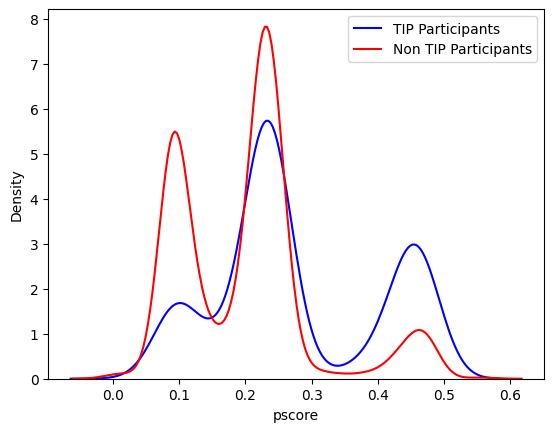

In [100]:
vars_to_check = [
    'year_TIP',
    'offense_before',
    'job_right_before_tip',
    'num_offenses_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()

psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])

X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')

plt.legend()

Given the diversity in propensity scores, it is best to use "caliper" matching to only match scores that are within a certain range of each other. This will help us to avoid matching participants with very different propensity scores, which could lead to biased results.

In [101]:
matched_exp['pscore'] = X_psm['pscore']

In [102]:
new_matched_exp = []
new_matched_treatment = []

matched_participant_pool = matched_exp[matched_exp['treatment'] == 0]

for tip_participant in matched_exp[matched_exp['treatment'] == 1].iterrows():
    tip_participant = tip_participant[1]
    matched_participants = matched_participant_pool[
        (matched_participant_pool['pscore'] >= tip_participant['pscore'] - 0.05) &
        (matched_participant_pool['pscore'] <= tip_participant['pscore'] + 0.05)
    ]
    if len(matched_participants) == 0:
        matched_participants = matched_participant_pool[
            (matched_participant_pool['pscore'] >= tip_participant['pscore'] - 0.1) &
            (matched_participant_pool['pscore'] <= tip_participant['pscore'] + 0.1)
        ]
    if len(matched_participants) == 0:
        continue

    cutoff = min(3, len(matched_participants))
    matched_participants = matched_participants.sample(cutoff, random_state=1).copy()
    matched_participant_pool = matched_participant_pool[
        (~matched_participant_pool['PCS_OFF_ID'].isin(matched_participants.dropna(subset=['PCS_OFF_ID'])['PCS_OFF_ID'])) &
        (~matched_participant_pool['interviewed_tip_id'].isin(matched_participants.dropna(subset=['interviewed_tip_id'])['interviewed_tip_id'])) 
    ]
    new_matched_exp.append(matched_participants)
    new_matched_treatment.append(tip_participant)

new_matched_exp = pd.concat(new_matched_exp, axis=0).drop_duplicates().reset_index(drop=True)
new_matched_treatment = pd.DataFrame(new_matched_treatment)

In [103]:
new_matched_exp = pd.concat([new_matched_exp, new_matched_treatment], axis=0).drop_duplicates().reset_index(drop=True)
new_matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start,pscore
0,1417950.0,NaN,474.0,Black,Male,NaN,0,1,0.0,0.0,0,0,0.0,True,2016,0.087646
1,1097794.0,NaN,1221.0,Black,Male,NaN,0,11,99281.0,271684.0,1,0,0.0,False,2020,0.123920
2,1907684.0,NaN,978.0,Black,Male,NaN,0,5,0.0,105666.0,0,0,0.0,False,2019,0.065986
3,663458.0,NaN,1486.0,White,Male,NaN,0,8,56544.0,56544.0,1,1,1280.0,False,2022,0.244372
4,NaN,2258.0,850.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,False,2018,0.231129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NaN,NaN,NaN,Black,Male,1764.0,1,2,0.0,0.0,0,1,54554.0,False,2023,0.082887
2778,NaN,NaN,NaN,Unknown,Unknown,1769.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130
2779,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023,0.077846
2780,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130


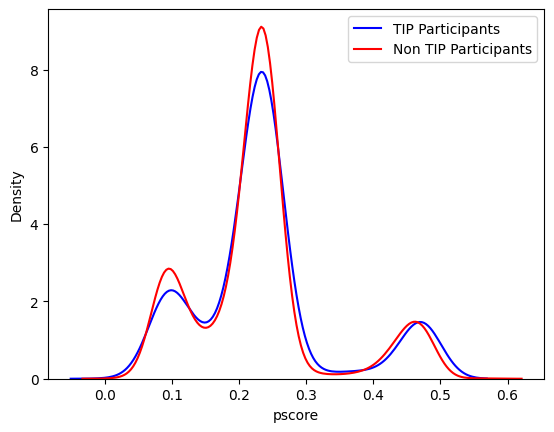

In [104]:
sns.kdeplot(new_matched_exp[new_matched_exp['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(new_matched_exp[new_matched_exp['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')

plt.legend()

In [105]:
Y_has_employment = new_matched_exp['employment_outcome'].values

X_values = new_matched_exp[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(new_matched_exp['year_start'].values.reshape(-1, 1))
# X_values['race_Black'] = (new_matched_exp['race'] == 'Black').astype(int)
# X_values['gender_Male'] = (new_matched_exp['gender'] == 'Male').astype(int)
X_values['offense_before'] = (new_matched_exp['num_offenses_before'] > 0).astype(int)

X_values['job_right_before_tip'] = new_matched_exp['job_right_before_tip'].astype(int)

X_values[['num_offenses_before']] = StandardScaler().fit_transform(new_matched_exp[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(new_matched_exp[['earnings_two_years_prior']].values)

# Interactions

X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
X_values['offense_before:treatment'] = X_values['offense_before'] * X_values['treatment']

vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.671521
year_TIP,1.497468
offense_before,2.257716
job_right_before_tip,1.802267
num_offenses_before,1.617853
earnings_two_years_prior,1.311167
treatment:year_TIP,1.381395
offense_before:treatment,1.932833


In [106]:
X_values = sm.add_constant(X_values)
logit_has_employment = sm.Logit(Y_has_employment, X_values).fit()

logit_has_employment.summary()

Optimization terminated successfully.
         Current function value: 0.456145
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2773
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.3366
Time:                        17:16:03   Log-Likelihood:                -1269.0
converged:                       True   LL-Null:                       -1912.8
Covariance Type:            nonrobust   LLR p-value:                1.153e-272
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.3085      0.088    -14.860      0.000      -1.481      -1.136
treatment                    1.0793      0.138      7.829      0.000       0.809       1.350
year_TIP                     0.4536      0.065      6.960      0.000       0.326       0.581
offense_before               0.2163      0.152      1.421      0.155      -0.082       0.515
job_right_before_tip         2.7764      0.148     18.766      0.000       2.486       3.066
num_offenses_before         -0.1041      0.069     -1.499      0.134      -0.240       0.032
earnings_two_years_prior     0.2389      0.113      2.112      0.035       0.017       0.461
treatment:year_TIP           0.6369      0.129      4.928      0.000       0.384       0.890
offense_before:treatment     0.2260      0.249      0.906      0.365      -0.263       0.715
============================================================================================
"""

Our model is as follows:

$$
\begin{aligned}
\text{logit}(p_i) = \;& \beta_0 + \beta_1 (\text{treatment}_i) 
\;+\; \beta_2 (\text{year\_TIP}_i) 
\;+\; \beta_3 (\text{offense\_before}_i) \\
& + \beta_4 (\text{job\_right\_before\_tip}_i)
+ \beta_5 (\text{num\_offenses\_before}_i)
+ \beta_6 (\text{earnings\_two\_years\_prior}_i) \\
& + \beta_7 (\text{treatment}_i \times \text{year\_TIP}_i)
+ \beta_8 (\text{offense\_before}_i \times \text{treatment}_i).
\end{aligned}
$$

- $\beta_1$ shows that at a baseline (Year = 2018, No Offense), participation with TIP increases the odds of employment by 2.91x. 
- $\beta_2$ shows that as years increase, we see a 54% increase in the odds of employment. (54% increase every 3.3 years)
- $\beta_4$ shows that having a job right before TIP increases the odds of employment by a massive 17x.
- $\beta_7$ shows that as years increase, as the years increase, we see a steeper increase in odds of employment for the treatment group (3x vs 1.5x). This suggests that TIP is becoming more effective over time, or that the participants are becoming more effective over time.

We see a strong positive association between TIP participation (treatment) and employment odds (around 3× higher odds for participants vs. controls), which becomes even stronger in later TIP years (rising to nearly 3× per additional year). Having a job right before TIP also sharply increases the odds of later employment. Meanwhile, accumulating prior offenses reduces the odds, and having a prior offense does not significantly alter the treatment effect

In [109]:
Y_offense = new_matched_exp['offense_outcome'].values
logit_has_offense = sm.Logit(Y_offense, X_values).fit()
logit_has_offense.summary()

Optimization terminated successfully.
         Current function value: 0.387231
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2773
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1106
Time:                        17:16:52   Log-Likelihood:                -1077.3
converged:                       True   LL-Null:                       -1211.3
Covariance Type:            nonrobust   LLR p-value:                 2.590e-53
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.0160      0.080    -12.780      0.000      -1.172      -0.860
treatment                   -2.0396      0.239     -8.527      0.000      -2.508      -1.571
year_TIP                     0.5425      0.071      7.678      0.000       0.404       0.681
offense_before              -2.0789      0.188    -11.056      0.000      -2.447      -1.710
job_right_before_tip         0.3702      0.136      2.725      0.006       0.104       0.637
num_offenses_before          0.2619      0.071      3.688      0.000       0.123       0.401
earnings_two_years_prior    -0.0038      0.055     -0.069      0.945      -0.112       0.104
treatment:year_TIP          -0.8350      0.175     -4.772      0.000      -1.178      -0.492
offense_before:treatment     2.5824      0.349      7.391      0.000       1.898       3.267
============================================================================================
"""

Our model is as follows:

$$
\begin{aligned}
\text{logit}(p_i) \;=\;& \beta_0 
\;+\; \beta_1(\text{treatment}_i) 
\;+\; \beta_2(\text{year\_TIP}_i) 
\;+\; \beta_3(\text{offense\_before}_i) 
\;+\; \beta_4(\text{job\_right\_before\_tip}_i)\\
&+\; \beta_5(\text{num\_offenses\_before}_i) 
\;+\; \beta_6(\text{earnings\_two\_years\_prior}_i)
\;+\; \beta_7(\text{treatment}_i \times \text{year\_TIP}_i)
\;+\; \beta_8(\text{offense\_before}_i \times \text{treatment}_i).
\end{aligned}
$$

This model is interesting - it seems to suggest that at a baseline, treatment does help reduce the probability of an Offense, and that this reduction has increased throughout the years. However, there is odd behavior where those with an offense before TIP have an increase in odds of having an offense if they do participate in TIP. 

In [110]:
new_matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start,pscore
0,1417950.0,NaN,474.0,Black,Male,NaN,0,1,0.0,0.0,0,0,0.0,True,2016,0.087646
1,1097794.0,NaN,1221.0,Black,Male,NaN,0,11,99281.0,271684.0,1,0,0.0,False,2020,0.123920
2,1907684.0,NaN,978.0,Black,Male,NaN,0,5,0.0,105666.0,0,0,0.0,False,2019,0.065986
3,663458.0,NaN,1486.0,White,Male,NaN,0,8,56544.0,56544.0,1,1,1280.0,False,2022,0.244372
4,NaN,2258.0,850.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,False,2018,0.231129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NaN,NaN,NaN,Black,Male,1764.0,1,2,0.0,0.0,0,1,54554.0,False,2023,0.082887
2778,NaN,NaN,NaN,Unknown,Unknown,1769.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130
2779,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023,0.077846
2780,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130


In [111]:
recid = new_matched_exp[new_matched_exp['num_offenses_before'] > 0].copy()

Y_recid = recid['offense_outcome'].values
X_values = recid[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(recid['year_start'].values.reshape(-1, 1))

X_values['offense_before'] = (recid['num_offenses_before'] > 0).astype(int)
X_values['job_right_before_tip'] = recid['job_right_before_tip'].astype(int)
X_values[['num_offenses_before']] = StandardScaler().fit_transform(recid[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(recid[['earnings_two_years_prior']].values)
X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']

vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.055889
year_TIP,1.473603
offense_before,2.477922
job_right_before_tip,1.397416
num_offenses_before,1.129818
earnings_two_years_prior,1.308388
treatment:year_TIP,1.347699


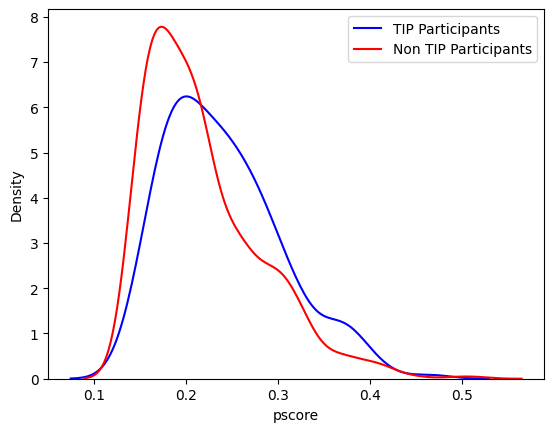

In [112]:
vars_to_check = [
    'year_TIP',
    'offense_before',
    'job_right_before_tip',
    'num_offenses_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()
psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])
X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')
plt.legend()

In [113]:
X_values = sm.add_constant(X_values)
logit_recid = sm.Logit(Y_recid, X_values).fit()
logit_recid.summary()

Optimization terminated successfully.
         Current function value: 0.289288
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 1034
Model:                          Logit   Df Residuals:                     1027
Method:                           MLE   Df Model:                            6
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06400
Time:                        17:17:02   Log-Likelihood:                -299.12
converged:                       True   LL-Null:                       -319.58
Covariance Type:            nonrobust   LLR p-value:                 3.025e-07
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
treatment                    0.0141      0.292      0.048      0.961      -0.557       0.586
year_TIP                    -0.6225      0.131     -4.747      0.000      -0.880      -0.365
offense_before              -2.6833      0.201    -13.375      0.000      -3.076      -2.290
job_right_before_tip         0.4837      0.278      1.740      0.082      -0.061       1.029
num_offenses_before          0.3088      0.093      3.324      0.001       0.127       0.491
earnings_two_years_prior    -0.0079      0.108     -0.073      0.942      -0.221       0.205
treatment:year_TIP          -0.0106      0.243     -0.044      0.965      -0.487       0.465
============================================================================================
"""

This model is not a strong predictor of whether or not someone will re-offend within 1.5 years of starting TIP. This makes sense, as we have far less data for later years.